Теоретическая разминка
1. Основная проблема переобучения:
   Модель слишком хорошо адаптируется к обучающим данным (в том числе к шуму), но плохо работает на новых данных — низкая обобщающая способность.

2. Почему нельзя оценивать качество на обучающих данных:
   Оценка будет слишком оптимистичной, не отражает реальную производительность на новых данных.

3. Регуляризация:
   Добавляет штрафной член к функции потерь, ограничивает коэффициенты модели, снижает сложность и предотвращает переобучение.

Набор данных Iris: логистическая регрессия (сравнение регуляризации)


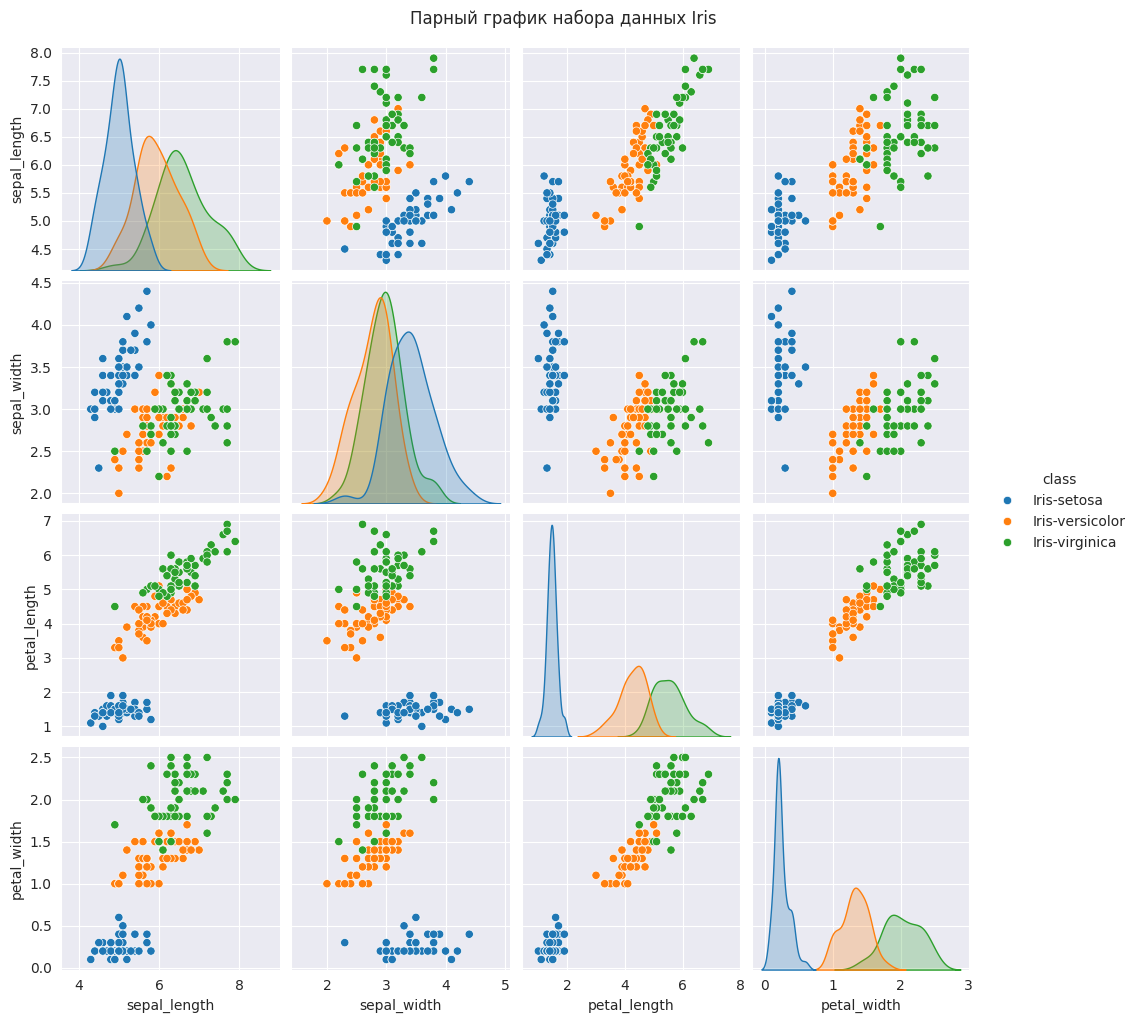


Точность (L2-регуляризация): 1.0000
Точность (без регуляризации): 1.0000


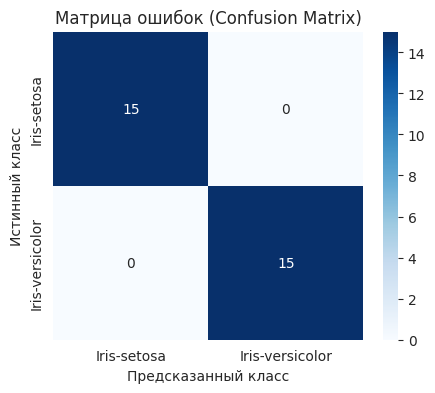


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        15

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Линейная регрессия: сравнение недообучения, подходящего обучения и переобучения


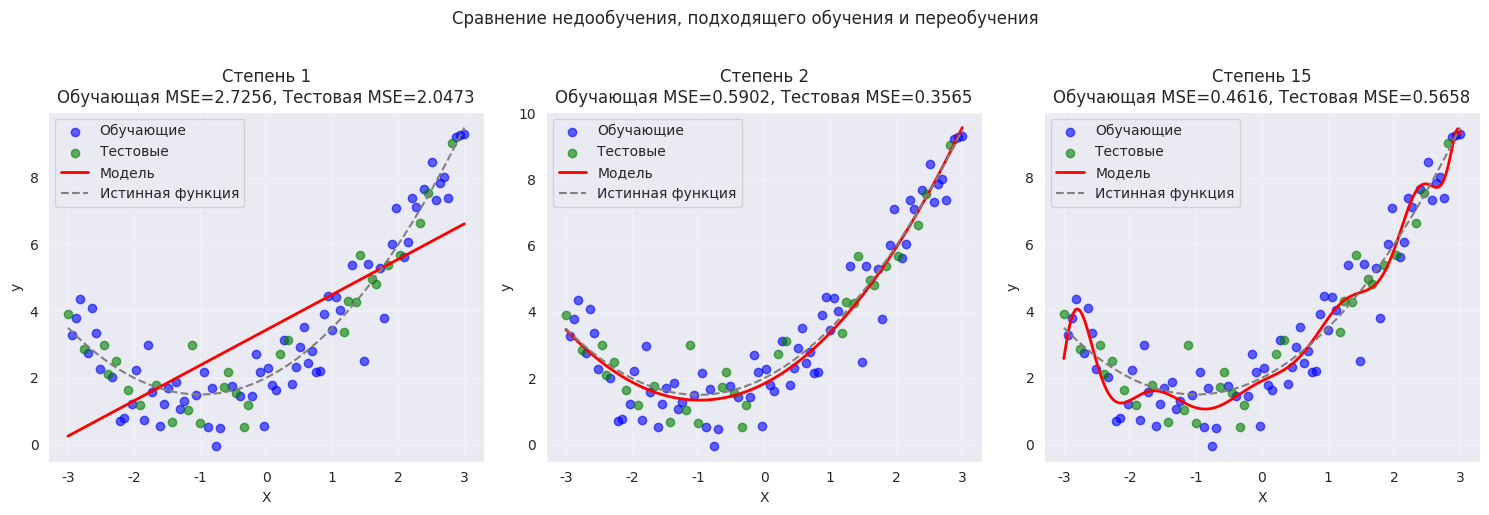


Сравнение MSE:
Степень 1 (недообучение)   - Обучающая MSE: 2.7256, Тестовая MSE: 2.0473
Степень 2 (подходящее)     - Обучающая MSE: 0.5902, Тестовая MSE: 0.3565
Степень 15 (переобучение)  - Обучающая MSE: 0.4616, Тестовая MSE: 0.5658

Регуляризация: сравнение Ridge (L2) и Lasso (L1) при разных alpha

MSE на тестовом наборе при разных alpha (сила регуляризации):
alpha		Ridge (L2)	Lasso (L1)
1e-06		0.565823	0.586280
1e-03		0.563981	0.583073
1e-02		0.552117	0.556403
1e-01		0.527197	0.602900
1e+00		0.513391	1.292933
1e+01		0.557304	1.814172
1e+02		0.865823	1.983282


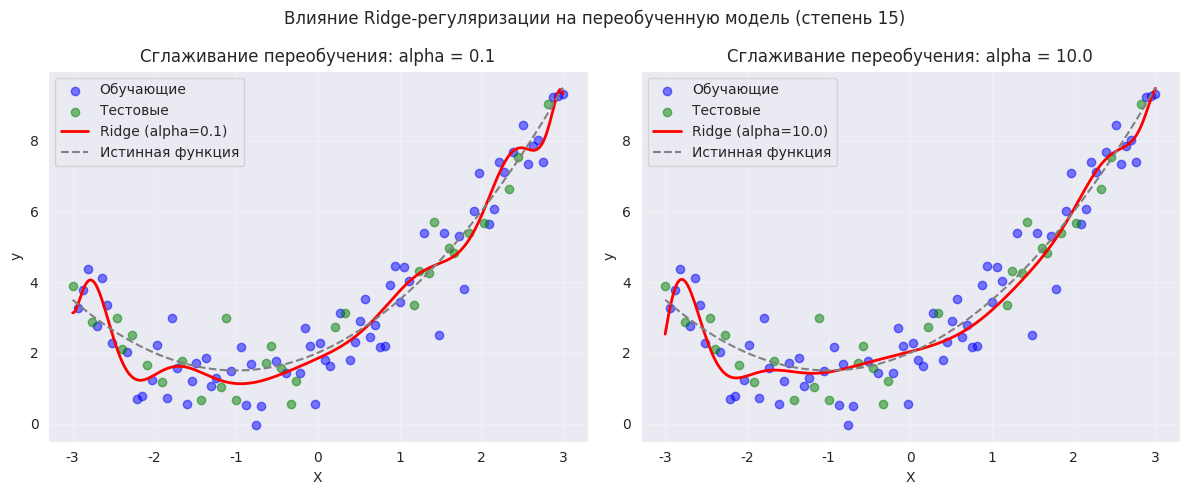


Итоги эксперимента
1. Недообучение: модель слишком простая, не может уловить закономерности (высокие MSE).
2. Подходящее обучение: сложность соответствует данным (низкие и близкие MSE).
3. Переобучение: модель слишком сложная, подгоняет шум (низкий MSE на обучении, высокий на тесте).
4. Регуляризация (Ridge/Lasso) эффективно снижает переобучение и улучшает обобщение.
5. Логистическая регрессия на Iris (Setosa vs Versicolor) даёт 100% точности; матрица ошибок и classification report подтверждают идеальное разделение классов.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（避免中文显示问题，这里使用系统默认，若需保证可用可取消注释下面两行）
# plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.rcParams['axes.unicode_minus'] = False

# ====================== 2. 理论问题回答 ======================
print("="*60)
print("Теоретическая разминка")  # 俄语：理论热身
print("="*60)
print("1. Основная проблема переобучения:")
print("   Модель слишком хорошо адаптируется к обучающим данным (в том числе к шуму), "
      "но плохо работает на новых данных — низкая обобщающая способность.")

print("\n2. Почему нельзя оценивать качество на обучающих данных:")
print("   Оценка будет слишком оптимистичной, не отражает реальную производительность на новых данных.")

print("\n3. Регуляризация:")
print("   Добавляет штрафной член к функции потерь, ограничивает коэффициенты модели, "
      "снижает сложность и предотвращает переобучение.")

# ====================== 3. Iris数据集：二分类逻辑回归 + 混淆矩阵 + 分类报告 ======================
print("\n" + "="*60)
print("Набор данных Iris: логистическая регрессия (сравнение регуляризации)")
print("="*60)

# 加载数据
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
iris_data = pd.read_csv(url, header=None, names=column_names)

# 可视化 pairplot
sns.pairplot(iris_data, hue="class")
plt.suptitle("Парный график набора данных Iris", y=1.02)
plt.savefig("iris_pairplot.png")
plt.show()

# 二分类数据预处理 (Setosa vs Versicolor)
iris_binary = iris_data[iris_data['class'].isin(['Iris-setosa', 'Iris-versicolor'])].copy()
le = LabelEncoder()
iris_binary['class'] = le.fit_transform(iris_binary['class'])   # 0: Setosa, 1: Versicolor

X = iris_binary.drop('class', axis=1)
y = iris_binary['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 逻辑回归：默认L2正则化 vs 无正则化
model_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=10000)
model_l2.fit(X_train_scaled, y_train)

model_no_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
model_no_reg.fit(X_train_scaled, y_train)

print(f"\nТочность (L2-регуляризация): {accuracy_score(y_test, model_l2.predict(X_test_scaled)):.4f}")
print(f"Точность (без регуляризации): {accuracy_score(y_test, model_no_reg.predict(X_test_scaled)):.4f}")

# 混淆矩阵和分类报告（使用L2模型）
y_pred = model_l2.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.savefig("confusion_matrix.png")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ====================== 4. 线性回归：欠拟合、合适拟合、过拟合对比 ======================
print("\n" + "="*60)
print("Линейная регрессия: сравнение недообучения, подходящего обучения и переобучения")
print("="*60)

# 生成合成数据：二次函数 + 噪声 (真实函数: y = 0.5*x^2 + x + 2)
np.random.seed(42)
X_syn = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = 0.5 * X_syn**2 + X_syn + 2
y_noisy = y_true + np.random.normal(0, 0.8, size=X_syn.shape)

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(X_syn, y_noisy, test_size=0.3, random_state=42)

degrees = [1, 2, 15]        # 1:欠拟合, 2:合适拟合, 15:过拟合
models = []
mse_train, mse_test = [], []

plt.figure(figsize=(15, 5))
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_syn)
    X_test_poly = poly.transform(X_test_syn)
    X_plot_poly = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_syn)
    models.append(model)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    mse_train.append(mean_squared_error(y_train_syn, y_train_pred))
    mse_test.append(mean_squared_error(y_test_syn, y_test_pred))

    plt.subplot(1, 3, i+1)
    plt.scatter(X_train_syn, y_train_syn, color='blue', alpha=0.6, label='Обучающие')
    plt.scatter(X_test_syn, y_test_syn, color='green', alpha=0.6, label='Тестовые')
    plt.plot(X_plot, model.predict(X_plot_poly), color='red', linewidth=2, label='Модель')
    plt.plot(X_plot, 0.5*X_plot**2 + X_plot + 2, 'gray', linestyle='--', label='Истинная функция')
    plt.title(f'Степень {deg}\nОбучающая MSE={mse_train[i]:.4f}, Тестовая MSE={mse_test[i]:.4f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(alpha=0.3)

plt.suptitle('Сравнение недообучения, подходящего обучения и переобучения', y=1.02)
plt.tight_layout()
plt.savefig("poly_fit_comparison.png")
plt.show()

print("\nСравнение MSE:")
print(f"Степень 1 (недообучение)   - Обучающая MSE: {mse_train[0]:.4f}, Тестовая MSE: {mse_test[0]:.4f}")
print(f"Степень 2 (подходящее)     - Обучающая MSE: {mse_train[1]:.4f}, Тестовая MSE: {mse_test[1]:.4f}")
print(f"Степень 15 (переобучение)  - Обучающая MSE: {mse_train[2]:.4f}, Тестовая MSE: {mse_test[2]:.4f}")

# ====================== 5. Регуляризация: влияние силы L2 и L1 на переобучение ======================
print("\n" + "="*60)
print("Регуляризация: сравнение Ridge (L2) и Lasso (L1) при разных alpha")
print("="*60)

# 使用严重过拟合的15阶多项式特征
poly_over = PolynomialFeatures(degree=15)
X_train_over = poly_over.fit_transform(X_train_syn)
X_test_over = poly_over.transform(X_test_syn)

alphas = [1e-6, 0.001, 0.01, 0.1, 1, 10, 100]
ridge_mses = []
lasso_mses = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_over, y_train_syn)
    y_pred = ridge.predict(X_test_over)
    ridge_mses.append(mean_squared_error(y_test_syn, y_pred))

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_over, y_train_syn)
    y_pred_l = lasso.predict(X_test_over)
    lasso_mses.append(mean_squared_error(y_test_syn, y_pred_l))

# 输出表格
print("\nMSE на тестовом наборе при разных alpha (сила регуляризации):")
print("alpha\t\tRidge (L2)\tLasso (L1)")
for a, r, l in zip(alphas, ridge_mses, lasso_mses):
    print(f"{a:.0e}\t\t{r:.6f}\t{l:.6f}")

# 可视化影响 (选择两个代表性alpha)
plt.figure(figsize=(12,5))
for idx, alpha in enumerate([0.1, 10.0]):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_over, y_train_syn)
    plt.subplot(1, 2, idx+1)
    plt.scatter(X_train_syn, y_train_syn, color='blue', alpha=0.5, label='Обучающие')
    plt.scatter(X_test_syn, y_test_syn, color='green', alpha=0.5, label='Тестовые')
    X_smooth = np.linspace(-3, 3, 300).reshape(-1, 1)
    X_smooth_poly = poly_over.transform(X_smooth)
    y_smooth = ridge.predict(X_smooth_poly)
    plt.plot(X_smooth, y_smooth, color='red', linewidth=2, label=f'Ridge (alpha={alpha})')
    plt.plot(X_plot, 0.5*X_plot**2 + X_plot + 2, 'gray', linestyle='--', label='Истинная функция')
    plt.title(f'Сглаживание переобучения: alpha = {alpha}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(alpha=0.3)

plt.suptitle('Влияние Ridge-регуляризации на переобученную модель (степень 15)')
plt.tight_layout()
plt.savefig("regularization_effect.png")
plt.show()

# ====================== 6. Итоги эксперимента ======================
print("\n" + "="*60)
print("Итоги эксперимента")
print("="*60)
print("1. Недообучение: модель слишком простая, не может уловить закономерности (высокие MSE).")
print("2. Подходящее обучение: сложность соответствует данным (низкие и близкие MSE).")
print("3. Переобучение: модель слишком сложная, подгоняет шум (низкий MSE на обучении, высокий на тесте).")
print("4. Регуляризация (Ridge/Lasso) эффективно снижает переобучение и улучшает обобщение.")
print("5. Логистическая регрессия на Iris (Setosa vs Versicolor) даёт 100% точности; матрица ошибок и classification report подтверждают идеальное разделение классов.")